# Linear Regression

In [119]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [120]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4


In [179]:
data = pd.read_csv("https://aegis4048.github.io/downloads/notebooks/sample_data/unconv_MV_v5.csv")
df = data[['Por', 'Prod']]
df


,Por,Prod
0,12.08,4165.196191
1,12.38,3561.146205
2,14.02,4284.348574
3,17.67,5098.680869
4,17.52,3406.132832
...,...,...
195,11.95,3847.571003
196,17.99,5601.227131
197,12.12,3409.575363
198,15.55,5087.592149


In [180]:
df.dropna(inplace=True)
df.isna().sum()

/tmp/ipykernel_818/3486782518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


,0
Por,0
Prod,0


<Axes: xlabel='Por', ylabel='Prod'>

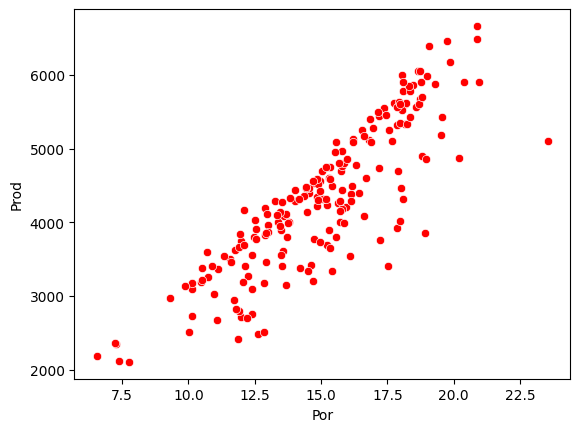

In [185]:
sns.scatterplot(df, x=df['Por'], y=df['Prod'], color='red')

In [186]:
regr = LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(np.array(df['Por']).reshape(-1,1), np.array(df['Prod']).reshape(-1,1), test_size = 0.15)


In [187]:
regr.fit(X_train, y_train)
print(regr.score(X_test, y_test))

0.6692185563732407


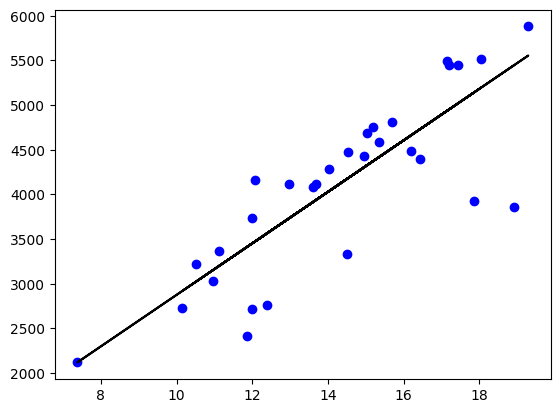

In [188]:
y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color ='b')
plt.plot(X_test, y_pred, color ='k')

plt.show()

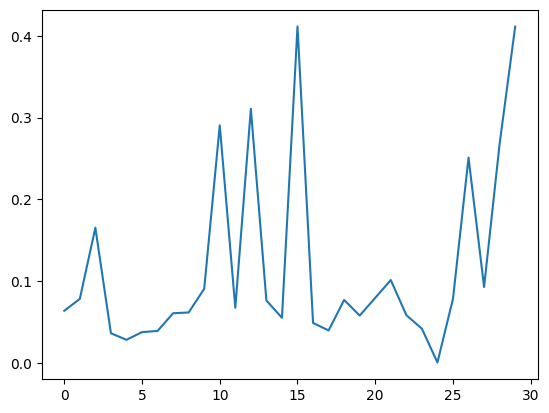

In [193]:
error = y_pred - y_test
plt.plot((abs(error)/y_test))
plt.show()

In [191]:
mse = np.mean(error**2)
print("MSE =",mse)
mae= np.mean(abs(error))
print("MAE =",mae)
huber = np.mean(0.5*(error**2))
print("Huber =",huber)

MSE = 312673.8639674603
MAE = 434.26365615417
Huber = 156336.93198373014


# Multi Variable Linear Regression

> Life Anganeyaa...



In [196]:
df =pd.read_csv('https://aegis4048.github.io/downloads/notebooks/sample_data/unconv_MV_v5.csv')
df

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832
...,...,...,...,...,...,...,...,...
195,196,11.95,3.13,2.97,67.18,0.80,2.06,3847.571003
196,197,17.99,9.87,3.38,44.32,0.98,2.08,5601.227131
197,198,12.12,2.27,3.52,57.07,-0.04,1.73,3409.575363
198,199,15.55,4.48,2.48,58.25,1.89,2.35,5087.592149


In [206]:
df = df.dropna()
df

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832
...,...,...,...,...,...,...,...,...
195,196,11.95,3.13,2.97,67.18,0.80,2.06,3847.571003
196,197,17.99,9.87,3.38,44.32,0.98,2.08,5601.227131
197,198,12.12,2.27,3.52,57.07,-0.04,1.73,3409.575363
198,199,15.55,4.48,2.48,58.25,1.89,2.35,5087.592149


In [203]:
x = df[[ 'Por', 'Perm']]
y = df['Prod']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [204]:
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Text(0.5, 0, 'Prod')

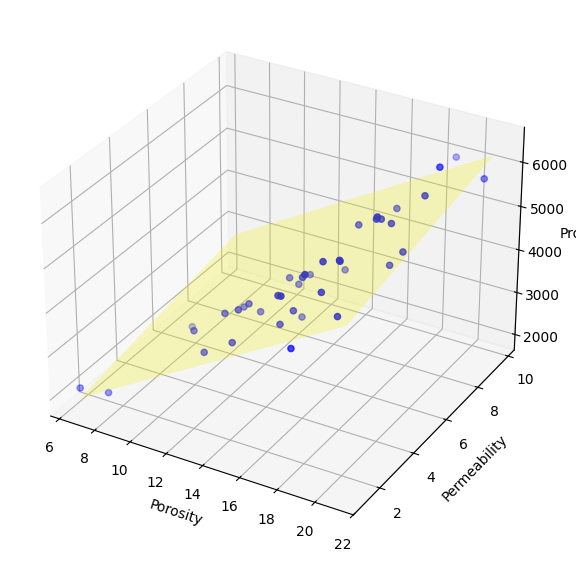

In [210]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['Por'], X_test['Perm'],
           y_test, color='blue', label='Actual Data')

x1_range = np.linspace(X_test['Por'].min(), X_test['Por'].max(), 100)
x2_range = np.linspace(X_test['Perm'].min(), X_test['Perm'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

z = model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color='yellow', alpha=0.25)

ax.set_xlabel('Porosity')
ax.set_ylabel('Permeability')
ax.set_zlabel('Prod')

<Axes: ylabel='Prod'>

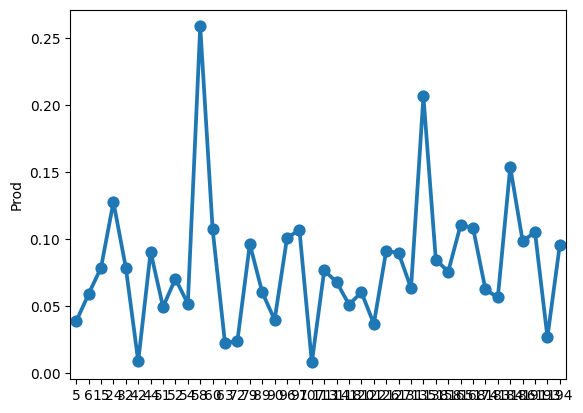

In [221]:
error = y_pred - y_test
sns.pointplot((abs(error)/y_test))


In [212]:
mae = np.mean(abs(y_pred - y_test))
print("MAE =",mae)
mse = np.mean((y_pred - y_test)**2)
print("MSE =",mse)
huber = np.mean(0.5*(y_pred - y_test)**2)
print("Huber =",huber)

MAE = 364.7914555982664
MSE = 177931.15314155392
Huber = 88965.57657077696
